# **Data selection**

TensorFlow version: 2.18.0
Eager execution: True


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.90Z6FJ_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Class names: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


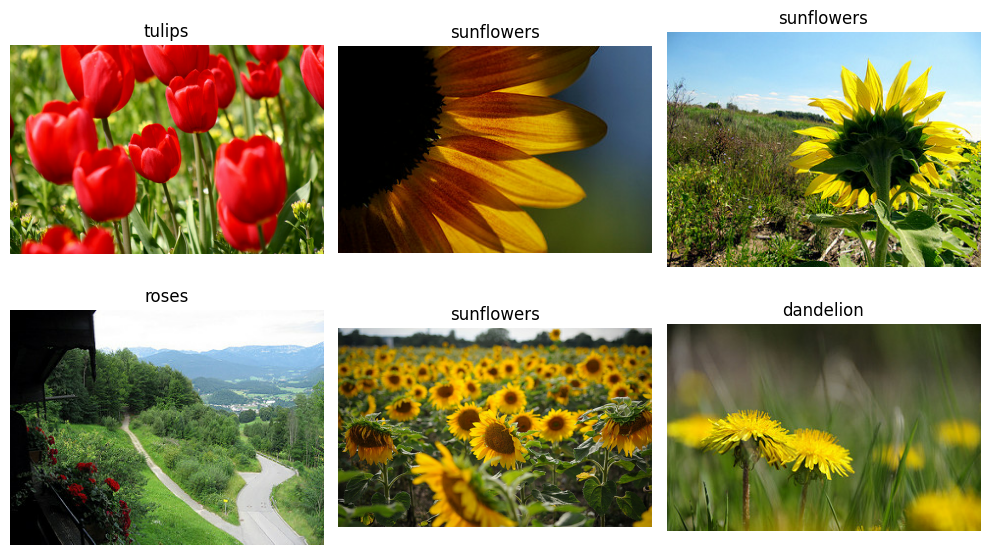

In [3]:
# Step 1: Import necessary libraries
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# Check versions (optional but useful)
print("TensorFlow version:", tf.__version__)
print("Eager execution:", tf.executing_eagerly())

# Step 2: Load the tf_flowers dataset
# - `split` divides data into training and validation
# - `as_supervised=True` returns (image, label) pairs
# - `with_info=True` gives extra dataset info (like class names)
(train_ds, val_ds), ds_info = tfds.load(
    'tf_flowers',
    split=['train[:85%]', 'train[85%:]'],  # 85% training, 15% validation
    as_supervised=True,
    with_info=True
)

# Step 3: Extract class names for future use
class_names = ds_info.features['label'].names
print("Class names:", class_names)

# Step 4: Visualize a few sample images from the dataset
plt.figure(figsize=(10, 6))
for i, (image, label) in enumerate(train_ds.take(6)):
    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[label.numpy()])
    plt.axis("off")
plt.tight_layout()
plt.show()


# **Model Implementation (Transfer Learning)**


**Data Preperation**

In [4]:

# Step:  Data Preparation for Transfer Learning


import tensorflow as tf

# Constants
IMG_SIZE = 224          # Target image size (width x height)
BATCH_SIZE = 32         # Images per batch
AUTOTUNE = tf.data.AUTOTUNE  # Performance optimization

# Data Augmentation Layer (only for training data)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),             # Normalize pixels (0-255 to 0-1)
    tf.keras.layers.RandomFlip("horizontal"),      # Flip images horizontally
    tf.keras.layers.RandomRotation(0.1),           # Rotate images slightly
    tf.keras.layers.RandomZoom(0.1),               # Zoom in slightly
])

# Preprocessing for Training Data

def preprocess_train(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))  # Resize to 224x224
    image = data_augmentation(image)                      # Apply augmentation
    return image, label

# Preprocessing for Validation Data

def preprocess_val(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))  # Resize to 224x224
    image = tf.cast(image, tf.float32) / 255.0             # Normalize (without augmentation)
    return image, label

# Apply Preprocessing, Batch, and Prefetch

train_batches = (
    train_ds
    .shuffle(1000)                                # Shuffle for randomness
    .map(preprocess_train, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)                           # Load next batch while GPU is training
)

val_batches = (
    val_ds
    .map(preprocess_val, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


# Preview a Batch

for images, labels in train_batches.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


**Pre-trained CNN Model**

In [5]:

# Step: Model Building using Transfer Learning


from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50

NUM_CLASSES = 5  # tf_flowers dataset has 5 flower categories

# Function to build model with any base

def build_model(base_model):
    # Freeze the base model to prevent training its layers initially
    base_model.trainable = False

    # Create a new model on top
    model = models.Sequential([
        base_model,  # Pre-trained CNN base
        layers.GlobalAveragePooling2D(),  # Reduces 4D -> 2D
        layers.Dense(128, activation='relu'),  # Custom dense layer
        layers.Dropout(0.3),                   # Dropout to prevent overfitting
        layers.Dense(NUM_CLASSES, activation='softmax')  # Final output layer
    ])

    return model


# Load Pre-trained MobileNetV2 (without top)

mobilenet_base = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,      # Don't include ImageNet classifier
    weights='imagenet'      # Load pretrained ImageNet weights
)

mobilenet_model = build_model(mobilenet_base)


# Load Pre-trained ResNet50 (without top)

resnet_base = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

resnet_model = build_model(resnet_base)

# Compile both models

mobilenet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Model summary

print("MobileNetV2 Model Summary:")
mobilenet_model.summary()

print("\nResNet50 Model Summary:")
resnet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
MobileNetV2 Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

**Evaluation**

In [6]:

# Step 4: Evaluation & Visualization for both models


import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

# Function: Plot training and validation accuracy/loss

def plot_training_history(history, model_name="Model"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{model_name}: Training and Validation Accuracy')

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(loc='upper right')
    plt.title(f'{model_name}: Training and Validation Loss')

    plt.tight_layout()
    plt.show()

# Function: Evaluate model using confusion matrix and report

def evaluate_model(model, val_batches, class_names, model_name="Model"):
    y_true = []
    y_pred = []

    for images, labels in val_batches:
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

    # Classification report
    print(f"{model_name} - Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

# Function: Show a few predictions with probabilities
def show_predictions(model, dataset, class_names, num_samples=5, model_name="Model"):
    images, labels = next(iter(dataset))  # Get one batch
    plt.figure(figsize=(15, 8))

    for i in range(num_samples):
        ax = plt.subplot(1, num_samples, i + 1)
        img = images[i]
        label = labels[i]

        img_resized = tf.image.resize(img, (224, 224)) / 255.0
        pred = model.predict(tf.expand_dims(img_resized, axis=0), verbose=0)[0]
        pred_label = np.argmax(pred)
        confidence = np.max(pred) * 100

        plt.imshow((img.numpy() * 255).astype("uint8"))
        title_color = "green" if pred_label == label.numpy() else "red"
        plt.title(f"{class_names[pred_label]} ({confidence:.1f}%)", color=title_color)
        plt.axis("off")

    plt.suptitle(f'{model_name} - Sample Predictions', fontsize=16)
    plt.tight_layout()
    plt.show()




### TRAIN MODEL
    # Train MobileNetV2 model and store its training history
mobilenet_history = mobilenet_model.fit(
    train_batches,
    validation_data=val_batches,
    epochs=2  # or any number of epochs you prefer
)

# Train ResNet50 model and store its training history
resnet_history = resnet_model.fit(
    train_batches,
    validation_data=val_batches,
    epochs=2
)



Epoch 1/2
98/98 ━━━━━━━━━━━━━━━━━━━━ 60s 485ms/step - accuracy: 0.6523 - loss: 0.8883 - val_accuracy: 0.8636 - val_loss: 0.4004
Epoch 2/2
98/98 ━━━━━━━━━━━━━━━━━━━━ 58s 316ms/step - accuracy: 0.8541 - loss: 0.4052 - val_accuracy: 0.8855 - val_loss: 0.3271
Epoch 1/2
98/98 ━━━━━━━━━━━━━━━━━━━━ 64s 511ms/step - accuracy: 0.2660 - loss: 1.6690 - val_accuracy: 0.3073 - val_loss: 1.5346
Epoch 2/2
98/98 ━━━━━━━━━━━━━━━━━━━━ 60s 364ms/step - accuracy: 0.3317 - loss: 1.5222 - val_accuracy: 0.3418 - val_loss: 1.5240


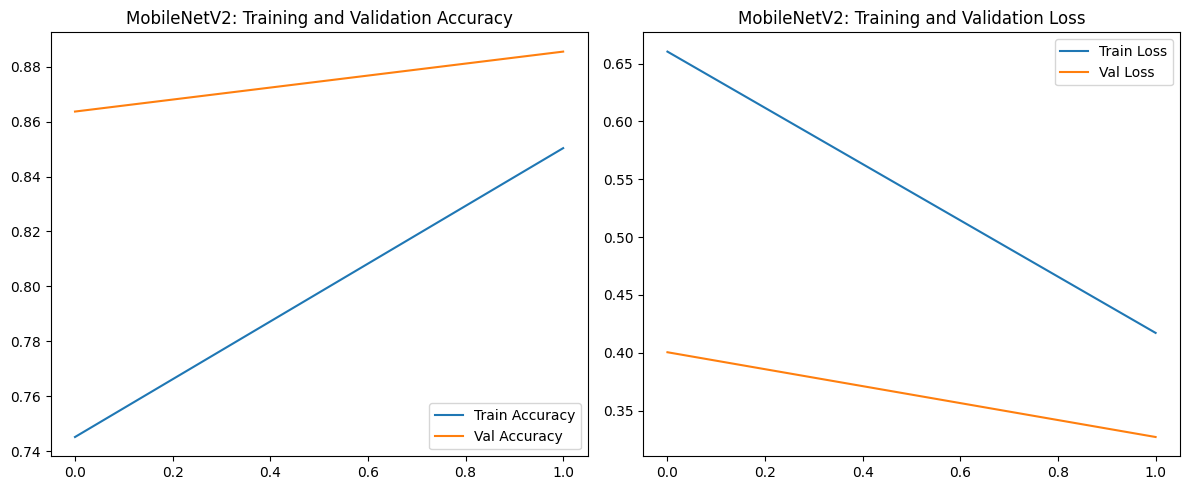

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


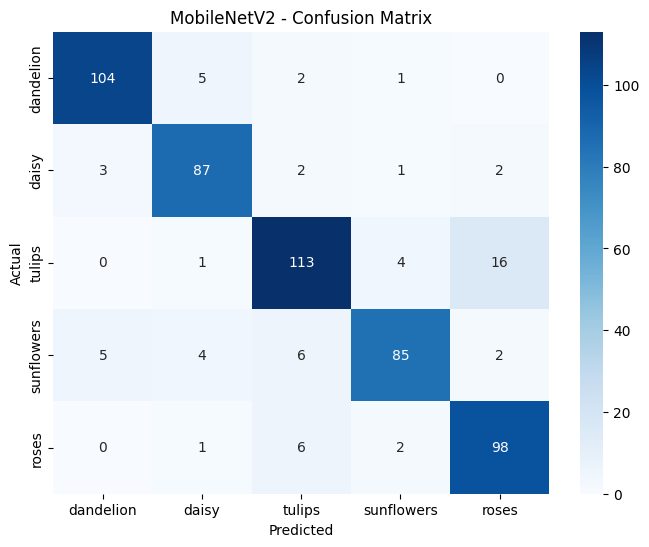

MobileNetV2 - Classification Report:

              precision    recall  f1-score   support

   dandelion       0.93      0.93      0.93       112
       daisy       0.89      0.92      0.90        95
      tulips       0.88      0.84      0.86       134
  sunflowers       0.91      0.83      0.87       102
       roses       0.83      0.92      0.87       107

    accuracy                           0.89       550
   macro avg       0.89      0.89      0.89       550
weighted avg       0.89      0.89      0.89       550



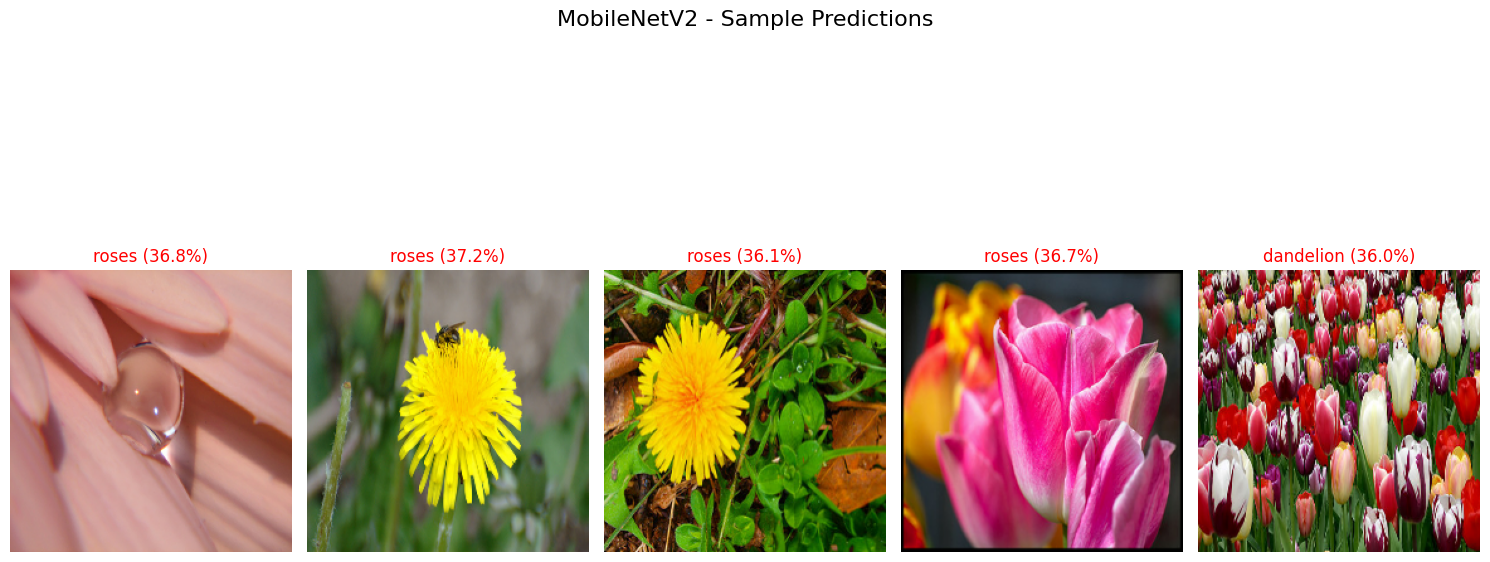

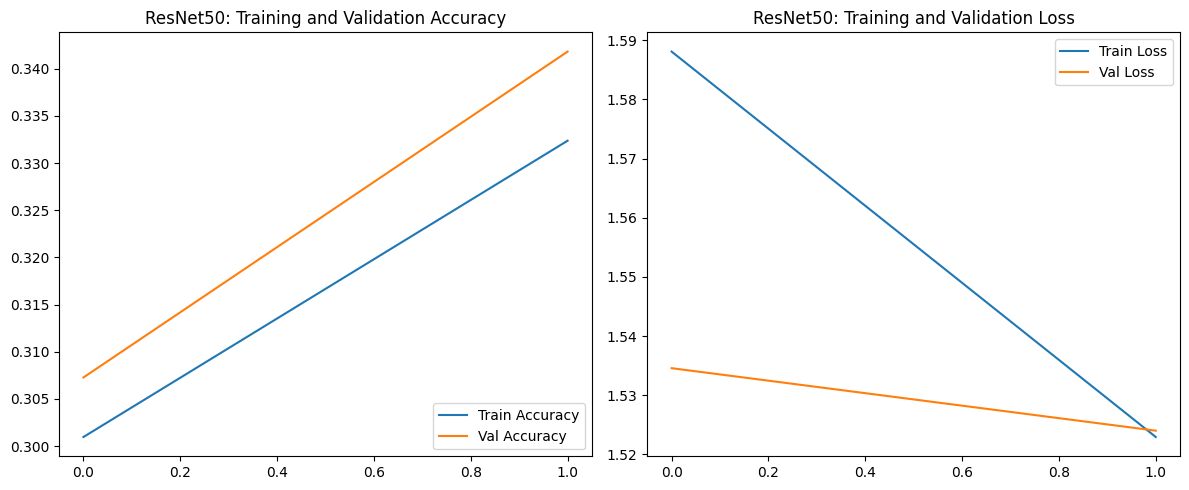

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


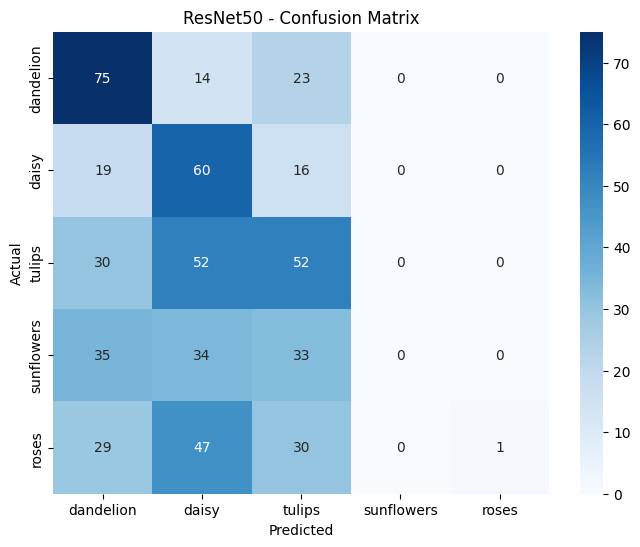

ResNet50 - Classification Report:

              precision    recall  f1-score   support

   dandelion       0.40      0.67      0.50       112
       daisy       0.29      0.63      0.40        95
      tulips       0.34      0.39      0.36       134
  sunflowers       0.00      0.00      0.00       102
       roses       1.00      0.01      0.02       107

    accuracy                           0.34       550
   macro avg       0.41      0.34      0.26       550
weighted avg       0.41      0.34      0.26       550



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


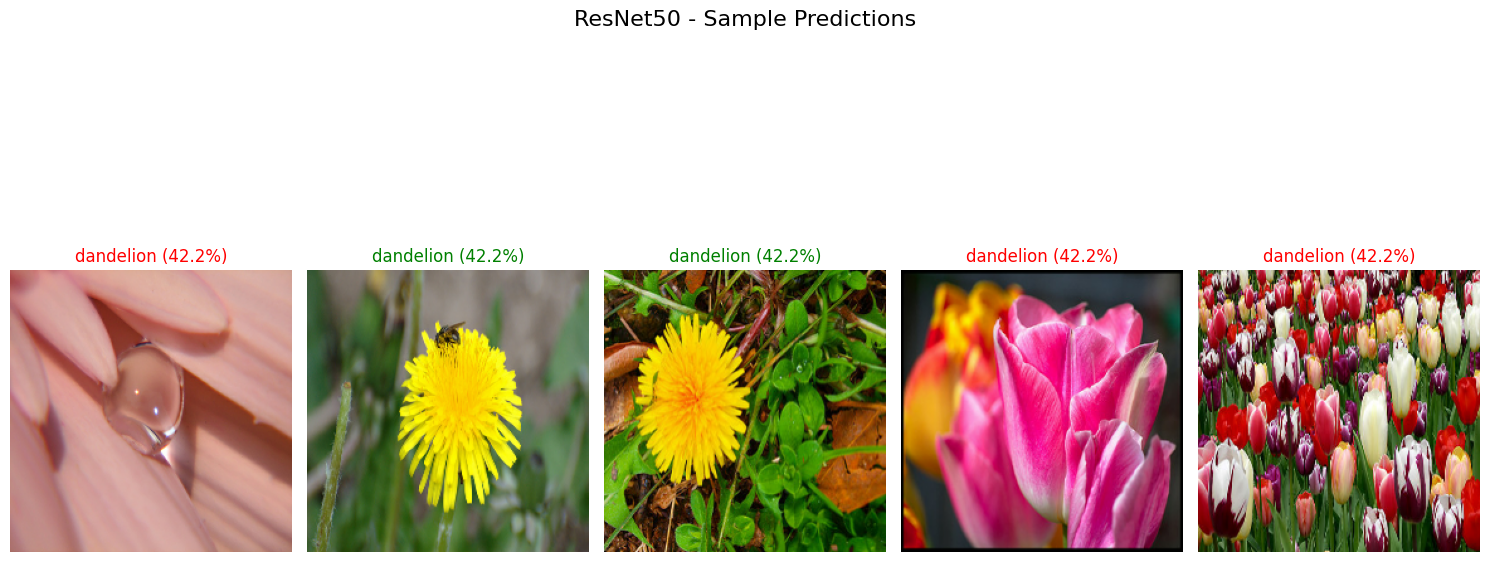

In [7]:
# --- MobileNetV2 ---
plot_training_history(mobilenet_history, model_name="MobileNetV2")
evaluate_model(mobilenet_model, val_batches, class_names, model_name="MobileNetV2")
show_predictions(mobilenet_model, val_batches, class_names, model_name="MobileNetV2")

# --- ResNet50 ---
plot_training_history(resnet_history, model_name="ResNet50")
evaluate_model(resnet_model, val_batches, class_names, model_name="ResNet50")
show_predictions(resnet_model, val_batches, class_names, model_name="ResNet50")



In [9]:
from google.colab import files

# Save models
mobilenet_model.save("mobilenet_model.h5")
resnet_model.save("resnet_model.h5")

# Download them to your computer
files.download("mobilenet_model.h5")
files.download("resnet_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
from google.colab import files

# Save models
mobilenet_model.save("mobilenet_model.keras")
resnet_model.save("resnet_model.keras")

# Download them to your computer
files.download("mobilenet_model.keras")
files.download("resnet_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>